<a href="https://colab.research.google.com/github/dinaglamshowroom/projet-data_oc/blob/main/Projet_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projet 6 Openclassroom - Détectez des faux billets

# Introduction & Objectifs

## Contexte du projet

## Objectif principal de l’étude

Construire un modèle explicatif du revenu futur d’un individu, en se basant sur des données très limitées :

* le revenu des parents,

* le revenu moyen de son pays,

* l’indice d’inégalité (indice de Gini) de ce pays.

L’enjeu est de prédire la capacité future de revenu d’un jeune prospect, enfant de client bancaire actuel, en vue de le cibler commercialement comme client à fort potentiel.

**Mission 1 – Exploration des données**


* Décrire le périmètre des données (année, couverture mondiale, nombre de pays, etc.)

* Identifier les quantiles utilisés (ici, des centiles)

* Justifier l’usage de ces quantiles : représentativité, granularité

* Expliquer la pertinence du $PPP pour la comparaison entre pays

**Mission 2 – Visualisations & inégalités**


* Visualiser la diversité des distributions de revenu (log(income) vs quantiles)

* Tracer la courbe de Lorenz pour plusieurs pays (visualisation de l’inégalité)

* Visualiser l’évolution de l’indice de Gini au fil des ans

* Comparer les pays : classement par Gini (top 5 égalitaires/inégalitaires + position de la France)

**Mission 3 – Simulation des revenus parentaux**


* Recréer une classe de revenu parentale pour chaque individu

* Utiliser la formule : (ln(Ychlid) = a + pj * ln(Yparents) + e

* Générer de grandes populations simulées pour estimer : P(Cparent|Cchlidpj)


* Produire un nouvel échantillon enrichi où chaque individu a :

  * un pays

  * un revenu moyen du pays

  * un indice de Gini

  * une classe de revenu parentale (simulée)

**Mission 4 – Modélisation statistique**



* ANOVA : mesurer la part de variance expliquée uniquement par le pays

* Régression linéaire 1 :

  * Variables explicatives : revenu moyen du pays + Gini

  * Calcul de la variance expliquée

  * Interprétation : que reste-t-il comme variance non expliquée ? (efforts, chance…)

* Régression linéaire 2 :

  * On ajoute la classe de revenu des parents

  * Nouvelle variance expliquée

  * Interprétation du coefficient Gini : favorise-t-il les riches ?

* Décomposition finale de la variance :

  * Part expliquée par le pays et la classe sociale d’origine

  * Part inexpliquée : mobilité sociale, aléa, mérite, etc.

## Notions à connaitre:

1. **Parité de Pouvoir d’Achat (PPP)**

L’unité des revenus dans les données est le PPP dollar, qui permet de comparer les revenus à travers les pays en neutralisant les différences de niveau de vie.

Ex : 1$ PPP représente le même panier de biens aux USA, en Inde ou en France.

2. **Indice de Gini**

Mesure l’inégalité des revenus dans un pays.

0 = parfaite égalité

1 = inégalité totale (une seule personne a tous les revenus)

3. **Quantiles**

Les données de revenu sont organisées en centiles (100 classes). Chaque individu est représenté par la classe de revenu à laquelle il appartient dans son pays.

4. **Élasticité intergénérationnelle (ρj)**

C’est un coefficient de transmission du revenu des parents à l’enfant.
Plus il est élevé, plus le revenu des parents détermine fortement celui de l’enfant (faible mobilité sociale).
C’est un paramètre crucial pour simuler les revenus des parents à partir des données disponibles.

** Résumé des Étapes Techniques**

* Importer et nettoyer les données (WID + Gini + population)

* Analyser les quantiles de revenus pour chaque pays

* Tracer les courbes : revenu/log-revenu vs quantiles

* Calculer ou importer les élasticités intergénérationnelles

* Simuler les classes parentales à partir des distributions

* Créer un super-échantillon 500x plus grand

* Construire les modèles statistiques

  * ANOVA

  * Régressions linéaires

* Comparer les performances des modèles

  * via le R²

  * via l’analyse des résidus (part inexpliquée)

## Question

1) **Générez un grand nombre n**
 de réalisations d'une variable que nous appellerons  ln(Yparent)
 selon une loi normale. Le choix de la moyenne et de l'écart type n'auront pas d'incidence sur le résultat final. n
 doit être supérieur à 1000 fois le nombre de quantiles.


2) **Générez n**
 réalisations du terme d'erreur ϵ
 selon une loi normale de moyenne 0 et d'écart type 1.


3) Pour une valeur donnée de ρj (par exemple 0.9), calculez ychild=eα+ρjln(yparent)+ϵ
 . Le choix de α
 n'a aucune incidence sur le résultat final et peut être supprimé. À ce stade, ychild
 contient des valeurs dont l'ordre de grandeur ne reflète pas la réalité, mais cela n3'a pas d'influence pour la suite.


4) Pour chacun des n
 individus générés, calculez la classe de revenu  ci,child
 ainsi que la classe de revenu de ses parents ci,parent
 , à partir de ychild
 et yparent
.


5) À partir de cette dernière information, estimez pour chaque  ci,child
 la distribution conditionnelle de ci,parent
 . Par exemple, si vous observez 6 individus ayant à la fois  ci,child=5
 et ci,parent=8
 , et que 200 individus sur 20000 ont ci,child=5
 , alors la probabilité d'avoir ci,parent=8
 sachant  ci,child=5
 et sachant ρj=0.9
 sera estimée à 6/200 (On note cette probabilité comme ceci : P(ci,parent=8|ci,child=5,ρj=0.9)=0.03). Si votre population est divisée en c
 classes de revenu, vous devriez alors avoir c2
estimations de ces probabilités conditionnelles, pour chaque pays.


6) Optionnellement et pour vérifier la cohérence de votre code, vous pouvez créer un graphique représentant ces distributions conditionnelles. Voici 2 exemples pour une population segmentée en 10 classes, pour 2 valeurs de ρj
 : l'une traduisant une forte mobilité (0.1) et l'autre une très faible mobilité (0.9) :

# Chargement & Préparation des Données

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os, glob
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy import stats
from sklearn import datasets
import zipfile
import os
from google.colab import files


In [2]:
# Création du dossier de stockage
os.makedirs("plots", exist_ok=True)

# Compteur de plots
_plot_counter = 1

# On intercepte matplotlib.show()
_old_show = plt.show

def _new_show(*args, **kwargs):
    global _plot_counter
    nom = f"plots/plot_{_plot_counter:03d}.png"
    plt.savefig(nom, dpi=300, bbox_inches="tight")
    _plot_counter += 1
    _old_show(*args, **kwargs)

plt.show = _new_show

## Importation du dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
DATA_DIR = "/content/drive/MyDrive/Projet_7"
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Fichiers CSV trouvés :")
for f in csv_files:
    print(f)

Fichiers CSV trouvés :
/content/drive/MyDrive/Projet_7/GDIMMay2018+(1).csv
/content/drive/MyDrive/Projet_7/world_income_distribution.csv
/content/drive/MyDrive/Projet_7/FAOSTAT_data_en_11-24-2025.csv
/content/drive/MyDrive/Projet_7/pop_total.csv
/content/drive/MyDrive/Projet_7/Correspondance_Pays-Continent2.csv
/content/drive/MyDrive/Projet_7/GINI.csv
/content/drive/MyDrive/Projet_7/df_main.csv
/content/drive/MyDrive/Projet_7/df_max.csv
/content/drive/MyDrive/Projet_7/df_max4.csv
/content/drive/MyDrive/Projet_7/df_max5.csv
/content/drive/MyDrive/Projet_7/df_main3.csv
/content/drive/MyDrive/Projet_7/df_cluster2.csv
/content/drive/MyDrive/Projet_7/selected_df2.csv


In [5]:
dfs = {f.split("/")[-1]: pd.read_csv(f) for f in csv_files}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

GDIMMay2018+(1).csv: (6504, 66)
world_income_distribution.csv: (11599, 7)
FAOSTAT_data_en_11-24-2025.csv: (1599, 15)
pop_total.csv: (1599, 5)
Correspondance_Pays-Continent2.csv: (216, 3)
GINI.csv: (271, 11)
df_main.csv: (11600, 9)
df_max.csv: (11600, 13)
df_max4.csv: (11600, 19)
df_max5.csv: (11600, 20)
df_main3.csv: (11600, 15)
df_cluster2.csv: (51, 6)
selected_df2.csv: (21, 8)


In [6]:
df_income = dfs["world_income_distribution.csv"]
df_gini = dfs["GINI.csv"]
df_GDI = dfs["GDIMMay2018+(1).csv"]
foa_pop = dfs["FAOSTAT_data_en_11-24-2025.csv"]
pays_continent = dfs["Correspondance_Pays-Continent2.csv"]


## Description des variables

In [7]:
df_income.describe()

,year_survey,quantile,nb_quantiles,income,pop,gdpppp
count,11599.000000,11599.000000,11599.0,11599.000000,11599.000000,1.139900e+04
mean,2007.982757,50.500819,100.0,6069.224260,16.178084,5.022128e+04
std,0.909633,28.868424,0.0,9414.185972,134.619280,4.000688e+05
min,2004.000000,1.000000,100.0,16.719418,0.003100,3.031931e+02
25%,2008.000000,25.500000,100.0,900.685515,0.052900,2.576000e+03
50%,2008.000000,51.000000,100.0,2403.244900,0.146998,7.560000e+03
75%,2008.000000,75.500000,100.0,7515.420900,0.456360,1.877300e+04
max,2011.000000,100.000000,100.0,176928.550000,1418.000000,4.300332e+06


## Vérification des données

### df_income

In [8]:

df_income.head(5)

,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
0,ALB,2008,1,100,728.89795,0.03143,7297.0
1,ALB,2008,2,100,916.66235,0.03143,7297.0
2,ALB,2008,3,100,1010.91600,0.03143,7297.0
3,ALB,2008,4,100,1086.90780,0.03143,7297.0
4,ALB,2008,5,100,1132.69970,0.03143,7297.0


In [9]:
df_income.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11599 entries, 0 to 11598
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       11599 non-null  object 
 1   year_survey   11599 non-null  int64  
 2   quantile      11599 non-null  int64  
 3   nb_quantiles  11599 non-null  int64  
 4   income        11599 non-null  float64
 5   pop           11599 non-null  float64
 6   gdpppp        11399 non-null  float64
dtypes: float64(3), int64(3), object(1)
memory usage: 634.4+ KB


In [10]:
annees = df_income["year_survey"].unique()
print(f"Année(s) des enquêtes : {annees}")

Année(s) des enquêtes : [2008 2009 2010 2007 2006 2011 2004]


In [11]:
for year in annees:
    df_year = df_income[df_income['year_survey'] == year]
    print(f"Année {year} : {df_year.shape[0]} éléments")

Année 2008 : 7599 éléments
Année 2009 : 1200 éléments
Année 2010 : 600 éléments
Année 2007 : 1500 éléments
Année 2006 : 500 éléments
Année 2011 : 100 éléments
Année 2004 : 100 éléments


In [12]:
df_income.loc[df_income['year_survey'] == 2004, 'country'].unique()

array(['SYR'], dtype=object)

In [13]:
df_income[df_income['year_survey'] == 2004]

,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
9899,SYR,2004,1,100,143.18066,0.196378,4512.0
9900,SYR,2004,2,100,179.06183,0.196378,4512.0
9901,SYR,2004,3,100,195.83022,0.196378,4512.0
9902,SYR,2004,4,100,210.05444,0.196378,4512.0
9903,SYR,2004,5,100,222.11244,0.196378,4512.0
...,...,...,...,...,...,...,...
9994,SYR,2004,96,100,1702.83960,0.196378,4512.0
9995,SYR,2004,97,100,1883.93970,0.196378,4512.0
9996,SYR,2004,98,100,2157.02400,0.196378,4512.0
9997,SYR,2004,99,100,2622.62130,0.196378,4512.0


In [14]:
df_income.loc[df_income['year_survey'] == 2011, 'country'].unique()


array(['GTM'], dtype=object)

In [15]:
df_income[df_income['year_survey'] == 2011]

,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
3900,GTM,2011,1,100,38.463615,0.136757,4367.0
3901,GTM,2011,2,100,101.680466,0.136757,4367.0
3902,GTM,2011,3,100,145.086870,0.136757,4367.0
3903,GTM,2011,4,100,180.353350,0.136757,4367.0
3904,GTM,2011,5,100,211.167390,0.136757,4367.0
...,...,...,...,...,...,...,...
3995,GTM,2011,96,100,6407.810500,0.136757,4367.0
3996,GTM,2011,97,100,7476.103500,0.136757,4367.0
3997,GTM,2011,98,100,9098.733000,0.136757,4367.0
3998,GTM,2011,99,100,12568.050000,0.136757,4367.0


Les enquêtes de revenu utilisées dans ce projet s’étendent sur plusieurs années, principalement autour de 2008, mais incluent également des données de 2004 à 2011.

In [16]:
n_pays = df_income["country"].nunique()
print(f"Nombre de pays distincts : {n_pays}")


Nombre de pays distincts : 116


In [17]:
df_income['country'].unique()


array(['ALB', 'ARG', 'ARM', 'AUT', 'AZE', 'BEL', 'BFA', 'BGD', 'BGR',
       'BIH', 'BLR', 'BOL', 'BRA', 'BTN', 'CAF', 'CAN', 'CHL', 'CHN',
       'CIV', 'CMR', 'COL', 'CRI', 'CYP', 'CZE', 'DEU', 'DNK', 'DOM',
       'ECU', 'EGY', 'ESP', 'EST', 'FIN', 'FJI', 'FRA', 'GBR', 'GEO',
       'GHA', 'GIN', 'GRC', 'GTM', 'HND', 'HRV', 'HUN', 'IDN', 'IND',
       'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JOR', 'JPN', 'KAZ',
       'KEN', 'KGZ', 'KHM', 'KOR', 'XKX', 'LAO', 'LBR', 'LKA', 'LTU',
       'LUX', 'LVA', 'MAR', 'MDA', 'MDG', 'MEX', 'MKD', 'MLI', 'MNE',
       'MNG', 'MOZ', 'MRT', 'MWI', 'MYS', 'NER', 'NGA', 'NIC', 'NLD',
       'NOR', 'NPL', 'PAK', 'PAN', 'PER', 'PHL', 'POL', 'PRT', 'PRY',
       'ROU', 'RUS', 'SDN', 'SLV', 'SRB', 'SVK', 'SVN', 'SWE', 'SWZ',
       'SYR', 'THA', 'TJK', 'TLS', 'TUR', 'TWN', 'TZA', 'UGA', 'UKR',
       'URY', 'USA', 'VEN', 'VNM', 'PSE', 'YEM', 'ZAF', 'COD'],
      dtype=object)

In [18]:
df_income.duplicated().sum()

np.int64(0)

In [19]:
df_income.nb_quantiles.nunique()


1

In [20]:
df_income.isnull().sum()

,0
country,0
year_survey,0
quantile,0
nb_quantiles,0
income,0
pop,0
gdpppp,200


In [21]:
# on cherche les p)ays correspondant aux NaN
print(df_income[df_income['gdpppp'].isna()].country.unique())

['XKX' 'PSE']


on remarque que les valeurs **gdpppp** sont manquantes  pour les codes pays **XKX (Kosovo)** et **PSE (Occupied Palestinian Territory)**

Nous allons chercher  les valeurs manquantes sur le site de "word Bank Group" et et regarder le **WDI** (NY.GDP.PCAP.PP.CD):

* **Kosovo (XKX)**: gdpppp 2008 = **7 249** $

* **Territoires palestiniens** (PSE): gdpppp 2008 = **4 972** $

In [22]:
df_income.loc[df_income.country=='XKX','gdpppp'] = 7249
df_income.loc[df_income.country=='PSE','gdpppp'] = 4972

In [23]:
df_income.loc[df_income.country=='XKX']

,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
5800,XKX,2008,1,100,437.89370,0.02,7249.0
5801,XKX,2008,2,100,508.17133,0.02,7249.0
5802,XKX,2008,3,100,591.82820,0.02,7249.0
5803,XKX,2008,4,100,668.00000,0.02,7249.0
5804,XKX,2008,5,100,730.40220,0.02,7249.0
...,...,...,...,...,...,...,...
5895,XKX,2008,96,100,5155.36470,0.02,7249.0
5896,XKX,2008,97,100,5689.52930,0.02,7249.0
5897,XKX,2008,98,100,6233.73930,0.02,7249.0
5898,XKX,2008,99,100,7366.67700,0.02,7249.0


**REMARQUE** La population associée au code XKX est incohérente avec celle du Kosovo seul.
Cela provient du fait qu’en 2008, les séries statistiques WDI ne séparaient pas encore le Kosovo de la Serbie : XKX renvoie donc à  **“Serbie + Kosovo”**.

In [24]:
df_income.loc[df_income.country=='PSE']

,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
11199,PSE,2009,1,100,195.28990,0.04,4972.0
11200,PSE,2009,2,100,264.36533,0.04,4972.0
11201,PSE,2009,3,100,301.44672,0.04,4972.0
11202,PSE,2009,4,100,329.83392,0.04,4972.0
11203,PSE,2009,5,100,348.76495,0.04,4972.0
...,...,...,...,...,...,...,...
11294,PSE,2009,96,100,2763.88480,0.04,4972.0
11295,PSE,2009,97,100,3077.83330,0.04,4972.0
11296,PSE,2009,98,100,3449.22240,0.04,4972.0
11297,PSE,2009,99,100,4165.99700,0.04,4972.0


On à la même incohérence au niveau de la population, après recherche:


**PSE = Palestine + diaspora** → explique le poids démographique artificiellement élevé.

In [25]:
df_income.isna().sum()

,0
country,0
year_survey,0
quantile,0
nb_quantiles,0
income,0
pop,0
gdpppp,0


In [26]:
df_income["nb_quantiles"].value_counts()


,count
nb_quantiles,
100,11599


Les revenus de chaque pays sont découpés en 100 quantiles

➡  il s’agit donc d’un **échantillonnage en centiles**.

L’usage des centiles permet une granularité maximale dans la représentation de l’échelle des revenus.
Cela facilite une analyse fine des inégalités, en mettant en évidence les écarts entre les couches extrêmes (1er centile vs 100e).
De plus, cet échantillonnage garantit une comparabilité directe entre pays, quel que soit leur niveau de développement.

**Remarque**:

Pour effectuer notre étude on suppose que chaque pays dispose de 100 quantiles:

Or dans df_income: n_pays contient 116 pays pour 11599 observations

➡  **il manque donc un quantile dans les données.**

In [27]:
# Liste des pays incomplets
pays_incomplets = []

# Parcours de tous les pays
for country in df_income["country"].unique():
    quantiles_pays = set(df_income[df_income["country"] == country]["quantile"])
    missing_q = sorted(set(range(1, 101)) - quantiles_pays)
    if missing_q:
        pays_incomplets.append((country, missing_q))

# Affichage des résultats
print(f"Nombre de pays avec données incomplètes : {len(pays_incomplets)}\n")
for pays, manquants in pays_incomplets:
    print(f" {pays} : {len(manquants)} quantile manquant : {manquants}")


Nombre de pays avec données incomplètes : 1

 LTU : 1 quantile manquant : [41]


La distribution des revenus n’est pas complète pour **LTU** : il manque **le 41e centile**, ce qui peut fausser les calculs futurs.

Pour corriger cela on aurait plusieurs options comme:
* Supprimer le pays ➡ as pertinent ici : la Lituanie est presque complète, ce serait du gaspillage.

* Régression locale ou spline ➡ trop lourd pour un seul point.

* On va donc procéder a une **interpolation linéaire**:
  * ➡  utiliser les centiles 40 et 42, et calculer la moyenne pour estimer le 41e.



In [28]:
# Sélection du pays
df_ltu = df_income[df_income["country"] == "LTU"]

# Extraire les lignes des quantiles 40 et 42
row_40 = df_ltu[df_ltu["quantile"] == 40]
row_42 = df_ltu[df_ltu["quantile"] == 42]

# Vérification
if not row_40.empty and not row_42.empty:
    # Fusionner les deux lignes en un seul DataFrame temporaire
    tmp = pd.concat([row_40, row_42])

    # Identifier les colonnes numériques à interpoler
    colonnes_numeriques = tmp.select_dtypes(include=["float64", "int64"]).columns

    # Interpolation linéaire sur ces colonnes
    valeurs_interp = tmp[colonnes_numeriques].mean().to_dict()

    # Création de la nouvelle ligne
    nouvelle_ligne = {
        "country": "LTU",
        "year_survey": int(row_40["year_survey"].values[0]),
        "quantile": 41,
        "nb_quantiles": 100,
        **valeurs_interp
    }

    # Ajouter la ligne au DataFrame principal
    df_income = pd.concat([df_income, pd.DataFrame([nouvelle_ligne])], ignore_index=True)

    # Réordonner le DataFrame
    df_income = df_income.sort_values(by=["country", "quantile"]).reset_index(drop=True)

    print(" Le quantile 41 a été interpolé et ajouté pour la Lituanie.")

else:
    print(" Impossible d’interpoler : quantiles 40 ou 42 manquants.")
print(nouvelle_ligne)



 Le quantile 41 a été interpolé et ajouté pour la Lituanie.
{'country': 'LTU', 'year_survey': 2008.0, 'quantile': 41.0, 'nb_quantiles': 100.0, 'income': 4882.14065, 'pop': 0.0335999987999999, 'gdpppp': 17571.0}


In [29]:
# @title
import pandas as pd



# Vérification des quantiles manquants pour LTU
df_ltu = df_income[df_income["country"] == "LTU"]
quantiles_ltu = df_ltu["quantile"].tolist()
if 41 in quantiles_ltu:
    print("✅ Le quantile 41 est déjà présent pour LTU.")
else:
    # Récupération des lignes 40 et 42
    row_40 = df_ltu[df_ltu["quantile"] == 40]
    row_42 = df_ltu[df_ltu["quantile"] == 42]

    if not row_40.empty and not row_42.empty:
        # Colonnes à interpoler
        income = (row_40["income"].values[0] + row_42["income"].values[0]) / 2
        pop = (row_40["pop"].values[0] + row_42["pop"].values[0]) / 2
        gdpppp = (row_40["gdpppp"].values[0] + row_42["gdpppp"].values[0]) / 2
        year = int(row_40["year_survey"].values[0])

        # Création de la ligne manquante
        ligne_41 = {
            "country": "LTU",
            "year_survey": year,
            "quantile": 41,
            "nb_quantiles": 100,
            "income": income,
            "pop": pop,
            "gdpppp": gdpppp
        }

        # Ajout au DataFrame
        df_income = pd.concat([df_income, pd.DataFrame([ligne_41])], ignore_index=True)

        # Tri final
        df_income = df_income.sort_values(by=["country", "quantile"]).reset_index(drop=True)

        print("✅ Le quantile 41 a été ajouté avec succès pour LTU.")
    else:
        print("❌ Les quantiles 40 ou 42 sont manquants. Interpolation impossible.")


✅ Le quantile 41 est déjà présent pour LTU.


In [30]:
df_income[(df_income["country"] == "LTU") & (df_income["quantile"].between(38, 45))]


,country,year_survey,quantile,nb_quantiles,income,pop,gdpppp
6237,LTU,2008.0,38.0,100.0,4756.43360,0.0336,17571.0
6238,LTU,2008.0,39.0,100.0,4802.36800,0.0336,17571.0
6239,LTU,2008.0,40.0,100.0,4868.45070,0.0336,17571.0
6240,LTU,2008.0,41.0,100.0,4882.14065,0.0336,17571.0
6241,LTU,2008.0,42.0,100.0,4895.83060,0.0336,17571.0
6242,LTU,2008.0,43.0,100.0,4950.63800,0.0336,17571.0
6243,LTU,2008.0,44.0,100.0,5006.78600,0.0336,17571.0
6244,LTU,2008.0,45.0,100.0,5028.54440,0.0336,17571.0


In [31]:
df_income.rename(columns={'country':'country_code', 'year_survey':'year'}, inplace=True)

**REMARQUE**


La variable **pop** ne représente pas la population d’un centile, mais un poids d’enquête (**survey weight**).

➡   **chaque centile** porte un poids correspondant à **1/100 de la population nationale**, mais exprimé en milliers plutôt qu’en individus.

In [32]:
df_income.head(5)

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0


# Indice de GINI

In [33]:
df_gini.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series Name    268 non-null    object 
 1   Series Code    266 non-null    object 
 2   Country Name   266 non-null    object 
 3   Country Code   266 non-null    object 
 4   2004 [YR2004]  76 non-null     float64
 5   2006 [YR2006]  82 non-null     float64
 6   2007 [YR2007]  72 non-null     float64
 7   2008 [YR2008]  79 non-null     float64
 8   2009 [YR2009]  83 non-null     float64
 9   2010 [YR2010]  86 non-null     float64
 10  2011 [YR2011]  82 non-null     float64
dtypes: float64(7), object(4)
memory usage: 23.4+ KB


In [34]:
gini=df_gini.copy()

In [35]:
gini.rename(columns={'Country Code':'country_code', 'Country Name':'country'}, inplace=True)

In [36]:
gini.drop(columns=['Series Name','Series Code',], inplace=True)

In [37]:
gini.head(50
)

,country,country_code,2004 [YR2004],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011]
0,World,WLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,NaN,NaN,NaN,30.0,NaN,NaN,NaN
3,Algeria,DZA,NaN,NaN,NaN,NaN,NaN,NaN,27.6
4,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Andorra,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Angola,AGO,NaN,NaN,NaN,42.7,NaN,NaN,NaN
7,Antigua and Barbuda,ATG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Argentina,ARG,48.5,46.4,46.3,45.0,43.8,43.7,42.7
9,Armenia,ARM,37.5,29.7,31.2,29.2,28.0,30.0,29.4


In [38]:
gini.rename(columns={'2004 [YR2004]':'2004', '2006 [YR2006]':'2006', '2007 [YR2007]':'2007', '2008 [YR2008]':'2008', '2009 [YR2009]':'2009', '2010 [YR2010]':'2010', '2011 [YR2011]':'2011'}, inplace=True)

In [39]:
gini.iloc[:,4:] = gini.iloc[:,4:]/100
gini.head(3)

,country,country_code,2004,2006,2007,2008,2009,2010,2011
0,World,WLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,NaN,NaN,NaN,0.3,NaN,NaN,NaN


In [40]:
df_gini2 = gini.melt(
    id_vars=["country", "country_code"],     # colonnes à conserver
    var_name="year",                         # nom de la nouvelle colonne contenant les années
    value_name="gini"                        # nom de la colonne des valeurs GINI
)

In [41]:
df_gini2.head()

,country,country_code,year,gini
0,World,WLD,2004,NaN
1,Afghanistan,AFG,2004,NaN
2,Albania,ALB,2004,NaN
3,Algeria,DZA,2004,NaN
4,American Samoa,ASM,2004,NaN


In [42]:
df_gini2["year"] = pd.to_datetime(df_gini2["year"], format="%Y", errors="coerce").dt.year

In [43]:
df_gini2


,country,country_code,year,gini
0,World,WLD,2004,NaN
1,Afghanistan,AFG,2004,NaN
2,Albania,ALB,2004,NaN
3,Algeria,DZA,2004,NaN
4,American Samoa,ASM,2004,NaN
...,...,...,...,...
1892,NaN,NaN,2011,NaN
1893,NaN,NaN,2011,NaN
1894,NaN,NaN,2011,NaN
1895,NaN,NaN,2011,NaN


In [44]:
df_gini2 = df_gini2.dropna(subset=["gini"])


In [45]:
df_gini2

,country,country_code,year,gini
8,Argentina,ARG,2004,48.500
9,Armenia,ARM,2004,37.500
11,Australia,AUS,2004,33.100
12,Austria,AUT,2004,29.800
13,Azerbaijan,AZE,2004,26.600
...,...,...,...,...
1832,United Kingdom,GBR,2011,0.332
1833,United States,USA,2011,0.412
1834,Uruguay,URY,2011,0.422
1840,West Bank and Gaza,PSE,2011,0.344


In [46]:
df_main = pd.merge(df_income, gini, how='left', on=['country_code'])
df_main

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11595,ZAF,2008.0,96.0,100.0,24553.56800,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11596,ZAF,2008.0,97.0,100.0,28858.03100,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11597,ZAF,2008.0,98.0,100.0,35750.29000,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11598,ZAF,2008.0,99.0,100.0,46297.31600,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN


In [47]:
df_main.to_csv("/content/drive/MyDrive/Projet_7/df_main3.csv", index=False)


In [48]:
df_main

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11595,ZAF,2008.0,96.0,100.0,24553.56800,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11596,ZAF,2008.0,97.0,100.0,28858.03100,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11597,ZAF,2008.0,98.0,100.0,35750.29000,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11598,ZAF,2008.0,99.0,100.0,46297.31600,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN


In [49]:
import pandas as pd

# Charger ton fichier
gini

# Colonnes exactes disponibles dans TON fichier
year_cols = [
    "2004",
    "2006",
    "2007",
    "2008",
    "2009",
    "2010",
    "2011"
]

# On garde uniquement les colonnes d'intérêt
df_check = gini[["country", "country_code"] + year_cols].copy()

# On sélectionnezUNIQUEMENT les pays qui ont des valeurs NON NA pour toutes ces années
df_complete = gini.dropna(subset=year_cols, how="any").reset_index(drop=True)

# Afficher le résultat
df_complete


,country,country_code,2004,2006,2007,2008,2009,2010,2011
0,Argentina,ARG,48.5,46.4,0.463,0.450,0.438,0.437,0.427
1,Armenia,ARM,37.5,29.7,0.312,0.292,0.280,0.300,0.294
2,Austria,AUT,29.8,29.6,0.306,0.304,0.315,0.303,0.308
3,Belarus,BLR,26.5,28.3,0.296,0.278,0.277,0.286,0.272
4,Belgium,BEL,30.5,28.1,0.292,0.284,0.286,0.284,0.281
5,Canada,CAN,33.8,34.1,0.338,0.339,0.340,0.336,0.327
6,Costa Rica,CRI,48.4,49.3,0.493,0.486,0.506,0.480,0.488
7,Cyprus,CYP,30.1,31.1,0.311,0.317,0.321,0.315,0.326
8,Czechia,CZE,27.5,26.7,0.260,0.263,0.262,0.266,0.264
9,Denmark,DNK,24.9,25.9,0.262,0.252,0.267,0.272,0.273


In [50]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11600 entries, 0 to 11599
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  11600 non-null  object 
 1   year          11600 non-null  float64
 2   quantile      11600 non-null  float64
 3   nb_quantiles  11600 non-null  float64
 4   income        11600 non-null  float64
 5   pop           11600 non-null  float64
 6   gdpppp        11600 non-null  float64
 7   country       11500 non-null  object 
 8   2004          7000 non-null   float64
 9   2006          7400 non-null   float64
 10  2007          6900 non-null   float64
 11  2008          7400 non-null   float64
 12  2009          7500 non-null   float64
 13  2010          7400 non-null   float64
 14  2011          7100 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.3+ MB


In [51]:
display(df_main.head())
display(df_main.tail())
display(df_main.shape)

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN


,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
11595,ZAF,2008.0,96.0,100.0,24553.568,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11596,ZAF,2008.0,97.0,100.0,28858.031,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11597,ZAF,2008.0,98.0,100.0,35750.290,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11598,ZAF,2008.0,99.0,100.0,46297.316,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN
11599,ZAF,2008.0,100.0,100.0,82408.550,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN


(11600, 15)

In [52]:
df_main.dtypes

,0
country_code,object
year,float64
quantile,float64
nb_quantiles,float64
income,float64
pop,float64
gdpppp,float64
country,object
2004,float64
2006,float64


In [53]:
display(df_main.isna().any())
display(df_main.duplicated().sum())

,0
country_code,False
year,False
quantile,False
nb_quantiles,False
income,False
pop,False
gdpppp,False
country,True
2004,True
2006,True


np.int64(0)

il manque un pays dans la colonne "country" dans notre df_main

In [54]:
missing_country = df_main[df_main["country"].isna()]["country_code"].unique()
print("Pays manquants dans la colonne 'country' :", missing_country)

Pays manquants dans la colonne 'country' : ['TWN']


In [55]:
df_main.loc[df_main["country_code"] == "TWN", "country"] = "Taiwan"

In [56]:
display(df_main.isna().any())

,0
country_code,False
year,False
quantile,False
nb_quantiles,False
income,False
pop,False
gdpppp,False
country,False
2004,True
2006,True


In [57]:
df_main[df_main["country_code"] == "CHN"]

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
1700,CHN,2007.0,1.0,100.0,16.719418,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1701,CHN,2007.0,2.0,100.0,234.150730,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1702,CHN,2007.0,3.0,100.0,282.894900,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1703,CHN,2007.0,4.0,100.0,323.826500,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1704,CHN,2007.0,5.0,100.0,362.260600,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,CHN,2007.0,96.0,100.0,7588.195000,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1796,CHN,2007.0,97.0,100.0,8317.553000,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1797,CHN,2007.0,98.0,100.0,9382.284000,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424
1798,CHN,2007.0,99.0,100.0,11071.510000,13.2564,5712.0,China,NaN,NaN,NaN,0.43,NaN,0.437,0.424


In [58]:
df_main[df_main["country_code"] == "TWN"]

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011
10500,TWN,2008.0,1.0,100.0,3477.1800,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10501,TWN,2008.0,2.0,100.0,4740.2637,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10502,TWN,2008.0,3.0,100.0,5331.3013,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10503,TWN,2008.0,4.0,100.0,5761.6577,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10504,TWN,2008.0,5.0,100.0,6093.2017,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10595,TWN,2008.0,96.0,100.0,38123.4600,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10596,TWN,2008.0,97.0,100.0,41663.7900,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10597,TWN,2008.0,98.0,100.0,46650.5820,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10598,TWN,2008.0,99.0,100.0,54016.9920,0.23,25342.0,Taiwan,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Remarque sur la présence de Taïwan dans les données**

Le jeu de données contient à la fois la Chine (CHN) et Taïwan (TWN).

Taïwan dispose d’un système économique propre, avec des revenus, un indice de Gini et une structure de population distincts.

 De nombreuses institutions telles que la Banque mondiale ou l’OCDE traitent Taïwan comme une entité séparée dans leurs bases de données économiques.

Cette séparation permet une analyse plus fine et plus rigoureuse de la distribution des revenus et des inégalités.

In [59]:
df_main.describe()

,year,quantile,nb_quantiles,income,pop,gdpppp,2004,2006,2007,2008,2009,2010,2011
count,11600.000000,11600.000000,11600.0,11600.000000,11600.000000,1.160000e+04,7000.000000,7400.000000,6900.000000,7400.000000,7500.000000,7400.000000,7100.000000
mean,2007.982759,50.500000,100.0,6069.121925,16.176693,4.945793e+04,37.142857,37.606757,0.362319,0.373878,0.365280,0.358135,0.356338
std,0.909593,28.867314,0.0,9413.786596,134.613560,3.966289e+05,8.844961,8.735242,0.080351,0.089775,0.080259,0.079690,0.076092
min,2004.000000,1.000000,100.0,16.719418,0.003100,3.031931e+02,24.800000,24.400000,0.244000,0.237000,0.248000,0.248000,0.246000
25%,2008.000000,25.750000,100.0,900.768507,0.052870,2.577500e+03,30.200000,30.200000,0.306000,0.308000,0.305000,0.301000,0.294000
50%,2008.000000,50.500000,100.0,2403.492950,0.145799,7.532500e+03,34.550000,35.500000,0.341000,0.344000,0.340000,0.336500,0.333000
75%,2008.000000,75.250000,100.0,7515.313700,0.453241,1.819625e+04,41.500000,44.700000,0.398000,0.450000,0.428000,0.401000,0.412000
max,2011.000000,100.000000,100.0,176928.550000,1418.000000,4.300332e+06,58.100000,57.500000,0.558000,0.630000,0.543000,0.634000,0.535000


In [60]:
gini

,country,country_code,2004,2006,2007,2008,2009,2010,2011
0,World,WLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,NaN,NaN,NaN,0.3,NaN,NaN,NaN
3,Algeria,DZA,NaN,NaN,NaN,NaN,NaN,NaN,0.276
4,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
df_gini2['gini'] = df_gini2['gini'] / 100

/tmp/ipython-input-2939061600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gini2['gini'] = df_gini2['gini'] / 100


In [62]:
print(df_gini2['gini'].describe())


count    560.000000
mean       0.108711
std        0.174202
min        0.002370
25%        0.003227
50%        0.003980
75%        0.280250
max        0.581000
Name: gini, dtype: float64


In [63]:
group_gini = df_gini2[["year", "country"]].drop_duplicates().groupby("year").count().reset_index()
group_gini.rename(columns={'year':'year_nb'}, inplace=True)
group_gini


,year_nb,country
0,2004,76
1,2006,82
2,2007,72
3,2008,79
4,2009,83
5,2010,86
6,2011,82


In [64]:
#Identification du nombre de pays par année
#Recherche des années les plus représentatives…
group_pays = df_main[['year', 'country']].drop_duplicates().groupby('year').count().reset_index()
group_pays.rename(columns={'country':'country_nb'}, inplace=True)
group_pays

,year,country_nb
0,2004.0,1
1,2006.0,5
2,2007.0,15
3,2008.0,76
4,2009.0,12
5,2010.0,6
6,2011.0,1


Text(0.5, 1.0, 'Nombre de pays dispo par année')

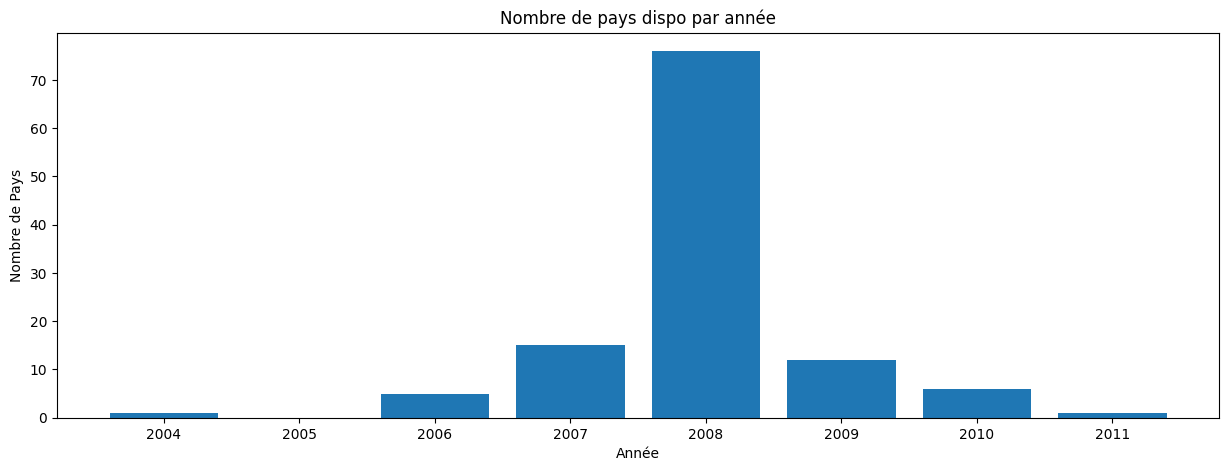

In [65]:
#Visualisation
fig, ax = plt.subplots(figsize=(15,5))
plt.bar(group_pays['year'], group_pays['country_nb'])

plt.xlabel('Année')
plt.ylabel('Nombre de Pays')
plt.title("Nombre de pays dispo par année")

In [66]:
foa_pop.head()

,Domain Code,Domain,Area Code (ISO3),Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,OA,Annual population,AFG,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2004,2004,1000 No,23560.654,X,Figure from external organization,NaN
1,OA,Annual population,AFG,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2006,2006,1000 No,25424.094,X,Figure from external organization,NaN
2,OA,Annual population,AFG,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2007,2007,1000 No,25909.852,X,Figure from external organization,NaN
3,OA,Annual population,AFG,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2008,2008,1000 No,26482.622,X,Figure from external organization,NaN
4,OA,Annual population,AFG,Afghanistan,511,Total Population - Both sexes,3010,Population - Est. & Proj.,2009,2009,1000 No,27466.100,X,Figure from external organization,NaN


In [67]:
pop_total = foa_pop.copy()

In [68]:
pop_total = pop_total[[ 'Area', 'Year', 'Value', 'Area Code (ISO3)']]

In [69]:
pop_total.rename(columns={'Area Code (ISO3)': 'country_code','Area': "country", 'Year':'year','Value':'pop_mille' }, inplace=True)

In [70]:
pop_total.head()

,country,year,pop_mille,country_code
0,Afghanistan,2004,23560.654,AFG
1,Afghanistan,2006,25424.094,AFG
2,Afghanistan,2007,25909.852,AFG
3,Afghanistan,2008,26482.622,AFG
4,Afghanistan,2009,27466.100,AFG


In [71]:
pop_total.to_csv("/content/drive/MyDrive/Projet_7/pop_total.csv")

In [72]:
pop_total['pop_pays'] = pop_total['pop_mille'] * 1000


In [73]:
pop_total.head()

,country,year,pop_mille,country_code,pop_pays
0,Afghanistan,2004,23560.654,AFG,23560654.0
1,Afghanistan,2006,25424.094,AFG,25424094.0
2,Afghanistan,2007,25909.852,AFG,25909852.0
3,Afghanistan,2008,26482.622,AFG,26482622.0
4,Afghanistan,2009,27466.100,AFG,27466100.0


In [74]:
pop_total_annee = pop_total.groupby("year")["pop_pays"].sum().reset_index()
print(pop_total_annee)

   year      pop_pays
0  2004  6.501402e+09
1  2006  6.669484e+09
2  2007  6.755346e+09
3  2008  6.842500e+09
4  2009  6.930814e+09
5  2010  7.019784e+09
6  2011  7.108972e+09


In [75]:
rename_dict = {
    'Bolivia': 'Bolivia (Plurinational State of)',
    'China': 'China, mainland',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Egypt, Arab Rep.': 'Egypt',
    'United Kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'Iran, Islamic Rep.': 'Iran (Islamic Republic of)',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Korea, Rep.': 'Republic of Korea',
    'Lao PDR': "Lao People's Democratic Republic",
    'Moldova': 'Republic of Moldova',
    'Netherlands': 'Netherlands (Kingdom of the)',
    'West Bank and Gaza': 'State of Palestine',
    'Sudan': 'Sudan',
    'Slovak Republic': 'Slovakia',
    'Turkiye': 'Türkiye',
    'Tanzania': 'United Republic of Tanzania',
    'United States': 'United States of America',
    'Venezuela, RB': 'Venezuela (Bolivarian Republic of)',
    'Kosovo': 'Kosovo',
    'Yemen, Rep.': 'Yemen'
}


In [76]:
pop_total = pop_total.merge(pop_total_annee, on=[ "year"], how="left")

In [77]:
pop_total.rename(columns={'pop_pays_x': 'pop_pays', 'pop_pays_y': 'pop_mondial'}, inplace=True)

In [78]:
pop_total

,country,year,pop_mille,country_code,pop_pays,pop_mondial
0,Afghanistan,2004,23560.654,AFG,23560654.0,6.501402e+09
1,Afghanistan,2006,25424.094,AFG,25424094.0,6.669484e+09
2,Afghanistan,2007,25909.852,AFG,25909852.0,6.755346e+09
3,Afghanistan,2008,26482.622,AFG,26482622.0,6.842500e+09
4,Afghanistan,2009,27466.100,AFG,27466100.0,6.930814e+09
...,...,...,...,...,...,...
1594,Zimbabwe,2007,12804.058,ZWE,12804058.0,6.755346e+09
1595,Zimbabwe,2008,12959.149,ZWE,12959149.0,6.842500e+09
1596,Zimbabwe,2009,13142.790,ZWE,13142790.0,6.930814e+09
1597,Zimbabwe,2010,13356.548,ZWE,13356548.0,7.019784e+09


In [79]:
df_main["country"] = df_main["country"].replace(rename_dict)


In [80]:
df_max = df_main.merge(pop_total, on=["country_code", "year"], how="left")

In [81]:
# Création d'un petit DataFrame avec les données manquantes à insérer
valeurs_manquantes = pd.DataFrame({
    "country_x": ["Sudan", "Kosovo"],
    "year": [2009, 2008],
    "pop_pays": [35652000, 1800000],  # À ajuster si nécessaire avec sources officielles
    "pop_mondial": [6800000000, 6800000000]  # Population mondiale approximative à ces dates
})

# Remplir les valeurs dans df_max
for _, row in valeurs_manquantes.iterrows():
    condition = (df_max["country_x"] == row["country_x"]) & (df_max["year"] == row["year"])
    df_max.loc[condition, "pop_pays"] = row["pop_pays"]
    df_max.loc[condition, "pop_mondial"] = row["pop_mondial"]


In [82]:
df_max.head()

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country_x,2004,2006,2007,2008,2009,2010,2011,country_y,pop_mille,pop_pays,pop_mondial
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,Albania,2992.93,2992930.0,6.842500e+09
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,Albania,2992.93,2992930.0,6.842500e+09
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,Albania,2992.93,2992930.0,6.842500e+09
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,Albania,2992.93,2992930.0,6.842500e+09
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,Albania,2992.93,2992930.0,6.842500e+09


In [83]:
missing_mondial = df_max[df_max['pop_mondial'].isna()][['country_code', 'year']]
missing_country = list(missing_mondial['country_code'].unique())
print(f"Nombre de pays sans mondial : {len(missing_country)}")
missing_mondial.head()


Nombre de pays sans mondial : 0


,country_code,year


In [84]:
df_max.describe()

,year,quantile,nb_quantiles,income,pop,gdpppp,2004,2006,2007,2008,2009,2010,2011,pop_mille,pop_pays,pop_mondial
count,11600.000000,11600.000000,11600.0,11600.000000,11600.000000,1.160000e+04,7000.000000,7400.000000,6900.000000,7400.000000,7500.000000,7400.000000,7100.000000,1.140000e+04,1.160000e+04,1.160000e+04
mean,2007.982759,50.500000,100.0,6069.121925,16.176693,4.945793e+04,37.142857,37.606757,0.362319,0.373878,0.365280,0.358135,0.356338,5.467540e+04,5.405558e+07,6.839941e+09
std,0.909593,28.867314,0.0,9413.786596,134.613560,3.966289e+05,8.844961,8.735242,0.080351,0.089775,0.080259,0.079690,0.076092,1.689174e+05,1.675349e+08,7.923399e+07
min,2004.000000,1.000000,100.0,16.719418,0.003100,3.031931e+02,24.800000,24.400000,0.244000,0.237000,0.248000,0.248000,0.246000,3.175140e+02,3.175140e+05,6.501402e+09
25%,2008.000000,25.750000,100.0,900.768507,0.052870,2.577500e+03,30.200000,30.200000,0.306000,0.308000,0.305000,0.301000,0.294000,4.768101e+03,4.715822e+06,6.842500e+09
50%,2008.000000,50.500000,100.0,2403.492950,0.145799,7.532500e+03,34.550000,35.500000,0.341000,0.344000,0.340000,0.336500,0.333000,1.468366e+04,1.468366e+07,6.842500e+09
75%,2008.000000,75.250000,100.0,7515.313700,0.453241,1.819625e+04,41.500000,44.700000,0.398000,0.450000,0.428000,0.401000,0.412000,4.042415e+04,3.863330e+07,6.842500e+09
max,2011.000000,100.000000,100.0,176928.550000,1418.000000,4.300332e+06,58.100000,57.500000,0.558000,0.630000,0.543000,0.634000,0.535000,1.325814e+06,1.325814e+09,7.108972e+09


In [85]:
gini.describe()


,2004,2006,2007,2008,2009,2010,2011
count,76.000000,82.000000,72.000000,79.000000,83.000000,86.000000,82.000000
mean,37.502632,37.689024,0.362597,0.373367,0.371651,0.362663,0.359671
std,9.152588,8.685009,0.080733,0.088432,0.085487,0.080165,0.076359
min,24.800000,24.400000,0.244000,0.237000,0.248000,0.248000,0.246000
25%,30.200000,30.225000,0.304750,0.308500,0.309000,0.302250,0.299250
50%,34.550000,35.650000,0.342000,0.346000,0.349000,0.337000,0.339500
75%,41.825000,42.750000,0.399250,0.431000,0.433000,0.401750,0.420000
max,58.100000,57.500000,0.558000,0.630000,0.610000,0.634000,0.535000


In [86]:
display(df_max.isna().any())

,0
country_code,False
year,False
quantile,False
nb_quantiles,False
income,False
pop,False
gdpppp,False
country_x,False
2004,True
2006,True


In [87]:
n_pays =df_max["pop_pays"].nunique()
print(f"Nombre de pays distincts : {n_pays}")


Nombre de pays distincts : 116


In [88]:
df_max[df_max["country_code"] == "XKX"]

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country_x,2004,2006,2007,2008,2009,2010,2011,country_y,pop_mille,pop_pays,pop_mondial
11300,XKX,2008.0,1.0,100.0,437.89370,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11301,XKX,2008.0,2.0,100.0,508.17133,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11302,XKX,2008.0,3.0,100.0,591.82820,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11303,XKX,2008.0,4.0,100.0,668.00000,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11304,XKX,2008.0,5.0,100.0,730.40220,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11395,XKX,2008.0,96.0,100.0,5155.36470,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11396,XKX,2008.0,97.0,100.0,5689.52930,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11397,XKX,2008.0,98.0,100.0,6233.73930,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09
11398,XKX,2008.0,99.0,100.0,7366.67700,0.02,7249.0,Kosovo,NaN,30.3,NaN,NaN,0.318,0.333,0.278,NaN,NaN,1800000.0,6.800000e+09


In [89]:
df_max[df_max["country_x"] == "Sudan"]

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country_x,2004,2006,2007,2008,2009,2010,2011,country_y,pop_mille,pop_pays,pop_mondial
9300,SDN,2009.0,1.0,100.0,148.52118,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9301,SDN,2009.0,2.0,100.0,214.12839,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9302,SDN,2009.0,3.0,100.0,242.30774,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9303,SDN,2009.0,4.0,100.0,269.11783,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9304,SDN,2009.0,5.0,100.0,296.48737,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9395,SDN,2009.0,96.0,100.0,2545.85800,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9396,SDN,2009.0,97.0,100.0,2786.10100,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9397,SDN,2009.0,98.0,100.0,3021.93480,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09
9398,SDN,2009.0,99.0,100.0,3548.41850,346.0,2345.0,Sudan,NaN,NaN,NaN,NaN,0.354,NaN,NaN,NaN,NaN,35652000.0,6.800000e+09


In [90]:
df_max.drop(columns=['pop_mille'], inplace=True)

In [91]:
df_max.drop(columns=['country_y'], inplace=True)

In [92]:
df_max['ratio_pop'] = round((df_max['pop_pays']/df_max['pop_mondial']*100), 3)

In [93]:
df_max.rename(columns={'country_x': 'country'}, inplace=True)

In [94]:
df_max.head()


,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011,pop_pays,pop_mondial,ratio_pop
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044


In [95]:
display(df_max.isna().any())

,0
country_code,False
year,False
quantile,False
nb_quantiles,False
income,False
pop,False
gdpppp,False
country,False
2004,True
2006,True


In [96]:
#Vérification des valeurs manquantes sur la Series 'gdpppp' et 'population'
display(df_max[df_max['gdpppp'].isna()]['country_code'].unique())
display(df_max[df_max['pop_pays'].isna()]['country_code'].unique())
display(df_max[df_max['pop_mondial'].isna()]['country_code'].unique())

array([], dtype=object)

array([], dtype=object)

array([], dtype=object)

In [97]:
l_nb_pays_gini = []

annees = sorted(df_gini2['year'].dropna().unique())

for annee in annees:
    df_annee = df_gini2[(df_gini2['year'] == annee) & (df_gini2['gini'].notna())]

    # Compter les pays uniques
    nb_pays_gini = df_annee['country'].nunique()
    l_nb_pays_gini.append((annee, nb_pays_gini))

    print(f" - Année {int(annee)} : {nb_pays_gini} pays")


 - Année 2004 : 76 pays
 - Année 2006 : 82 pays
 - Année 2007 : 72 pays
 - Année 2008 : 79 pays
 - Année 2009 : 83 pays
 - Année 2010 : 86 pays
 - Année 2011 : 82 pays


In [98]:
df_max.to_csv("/content/drive/MyDrive/Projet_7/df_max4.csv")

### Résumé de notre df_max:

**Définition de nos variables:**

* **country_code** ➡	Code ISO à 3 lettres de chaque pays.

* **year** ➡	Année d’observation (2004 à 2011).

* **quantile** ➡	Position dans la distribution des revenus (de 1 à 100).

* **nb_quantiles** ➡	Nombre total de quantiles (100, ce qui signifie des centiles).
* **income** ➡	Revenu moyen par quantile, exprimé en dollars PPA (Purchasing Power Parity).
* **pop** ➡	Poids du quantile dans la population (en proportion, somme = 1 par pays).
* **gdpppp** ➡ 	PIB par habitant (PPA).
* **country** ➡	Nom du pays.
* **gini** ➡	Indice de Gini mesurant les inégalités.
* **pop_pays** ➡	Population absolue du pays pour l’année donnée.
* **pop_mondial** ➡	Population mondiale totale pour l’année donnée.
* **ratio_pop** ➡ ratio de la population du pays / population mondiale

On pourra ainsi voir:

* Inégalités de revenu au sein des pays, par quantiles (100 centiles).

* Évolution de ces inégalités dans le temps (de 2004 à 2011).

* Poids démographique des pays, comparé à la population mondiale.

* PPA (Parité de pouvoir d’achat) : les revenus sont comparables entre pays.

#### Cohérence des données:

* Les valeurs des populations mondialessont tirées de la FAO

* Les revenus (income) en $PPP sont compatibles avec les méthodologies utilisées par la Banque Mondiale.

* L'indice de Gini se situe dans une plage réaliste (0.23 à 0.63).

#### Points de Vigilance:


Il faudra vérifier que :

* La somme des pop par année ≈ pop_pays pays (ou au moins en cohérence logique).

* Les pays sans Gini ont été imputés manuellement

# Partie 2: Analyse exploratoire des inégalités (Mission 2)

* Montrer la diversité des distributions de revenu à l’aide de graphiques log-log

* Représenter les courbes de Lorenz pour chaque pays choisi

* Visualiser l'évolution temporelle de l'indice de Gini

* Résumer les valeurs extrêmes (pays les plus égalitaires et inégalitaires)

## Montrer la diversité des distributions de revenu à l’aide de graphiques

**Méthode choisie**

“J’ai choisi la période la plus représentée dans le jeu de données, c’est-à-dire l’année pour laquelle au moins 70 % des pays disposent d’une donnée d’inégalité (indice de Gini).”

 **Étapes concrètes** :

* Compter le nombre de pays ayant des données pour chaque année.

* Calculer le pourcentage de couverture (nombre de pays avec données / total de pays).

* Choisir la pariode pour laquelle ce pourcentage de pays présents atteint ou dépasse 50 %.

dendogramme

kmeans

silouette ou elbo a choisir

PIB
continent
periode représentative
GINi

In [99]:
# Choisir une année de référence
ref_year = 2008
df_ref = df_gini2[df_gini2["year"] == ref_year].drop_duplicates(subset=["country"])

print("Worst Gini countries")
display(df_ref.sort_values(by='gini', ascending=False)[['country_code', 'country', 'gini']].head())

print("Best Gini countries")
display(df_ref.sort_values(by='gini', ascending=True)[['country_code', 'country', 'gini']].head())

# Moyenne
gini_mean = df_ref['gini'].mean()
print(f"Gini moyen en {ref_year} : {gini_mean:.3f}")

# Position de la France
gini_ranking = df_ref.sort_values(by='gini', ascending=False).reset_index(drop=True)
france_pos = gini_ranking[gini_ranking['country'] == 'France'].index[0] + 1
print(f"La France est à la position {france_pos} dans le classement mondial des Gini ({ref_year}).")


Worst Gini countries


,country_code,country,gini
991,ZAF,South Africa,0.00630
851,CAF,Central African Republic,0.00562
899,HND,Honduras,0.00555
856,COL,Colombia,0.00553
840,BRA,Brazil,0.00540


Best Gini countries


,country_code,country,gini
988,SVN,Slovenia,0.00237
867,DNK,Denmark,0.00252
987,SVK,Slovak Republic,0.00260
866,CZE,Czechia,0.00263
1017,UKR,Ukraine,0.00266


Gini moyen en 2008 : 0.004
La France est à la position 49 dans le classement mondial des Gini (2008).


In [100]:
worst_2008 = ['ZAF', 'CAF', 'HND', 'COL', 'BRA']

In [101]:
best_2008 = ['SVN', 'DNK', 'SVK', 'CZE', 'UKR']



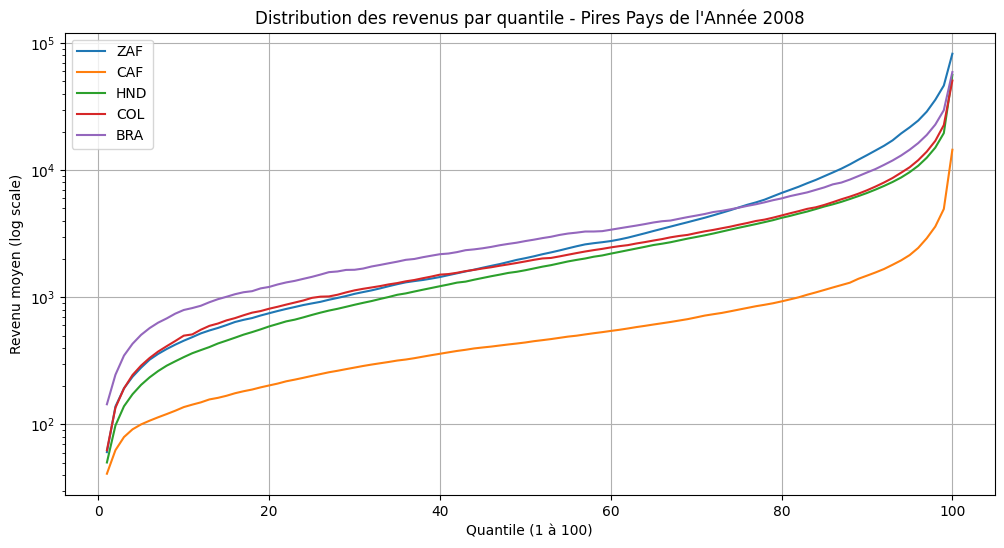

In [102]:


plt.figure(figsize=(12, 6))

for code in worst_2008:
    df_pays = df_max[(df_max["country_code"] == code) & (df_max["year"] == 2008)]

    # Vérifie si on a bien des données
    if df_pays.empty:
        print(f"Aucune donnée pour {code} en 2008.")
        continue

    df_pays = df_pays.sort_values(by="quantile")
    plt.plot(df_pays["quantile"], df_pays["income"], label=code)

plt.yscale("log")
plt.xlabel("Quantile (1 à 100)")
plt.ylabel("Revenu moyen (log scale)")
plt.title("Distribution des revenus par quantile - Pires Pays de l'Année 2008")
plt.legend()
plt.grid(True)
plt.show()



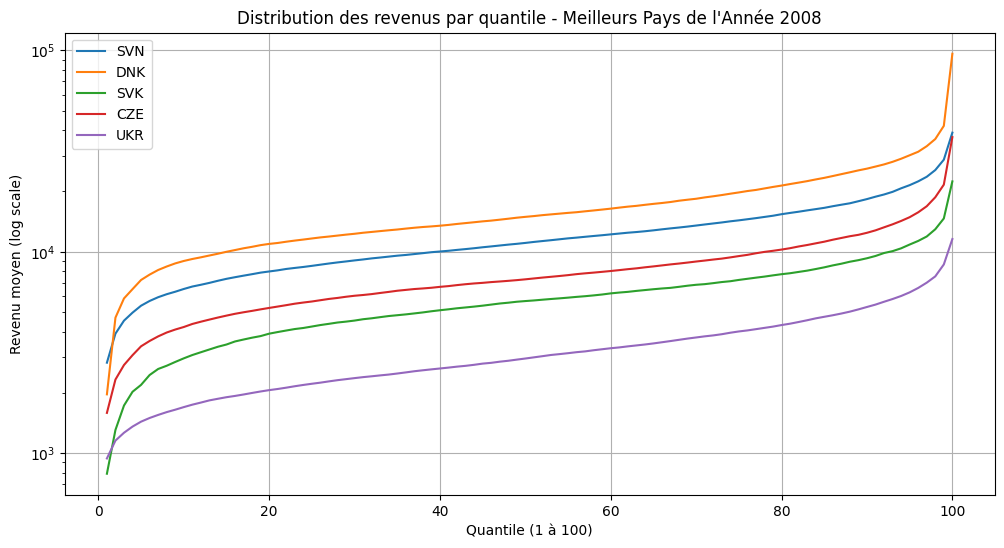

In [103]:
plt.figure(figsize=(12, 6))

for code in best_2008:
    df_pays = df_max[(df_max["country_code"] == code) & (df_max["year"] == 2008)]
    df_pays = df_pays.sort_values(by="quantile")
    plt.plot(df_pays["quantile"], df_pays["income"], label=code)

plt.yscale("log")
plt.xlabel("Quantile (1 à 100)")
plt.ylabel("Revenu moyen (log scale)")
plt.title("Distribution des revenus par quantile - Meilleurs Pays de l'Année 2008")
plt.legend()
plt.grid(True)
plt.show()


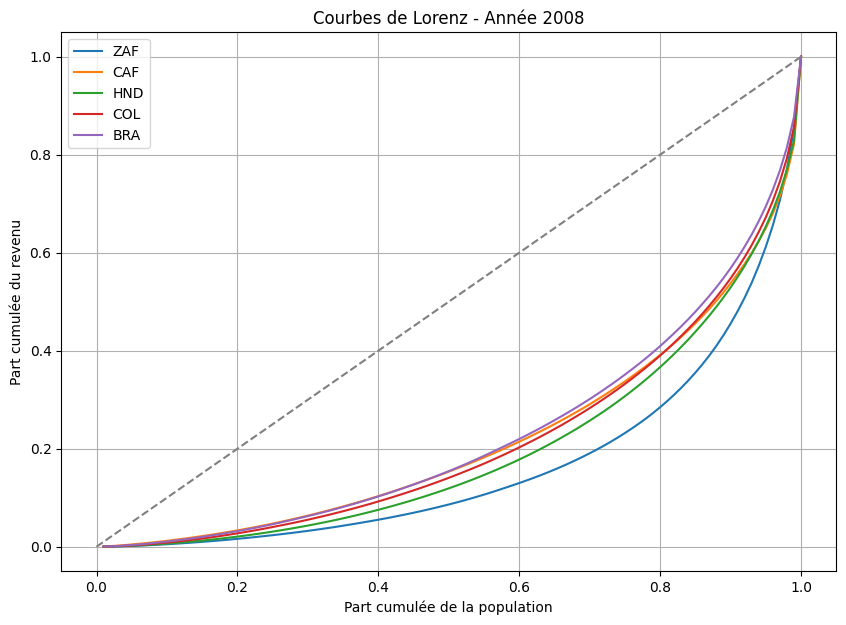

In [104]:


plt.figure(figsize=(10, 7))

for code in worst_2008:
    df_pays = df_max[(df_max["country_code"] == code) & (df_max["year"] == 2008)]
    df_pays = df_pays.sort_values("income")

    # Check if df_pays is empty before proceeding
    if not df_pays.empty:
        cum_pop = np.cumsum(df_pays["pop"])
        cum_income = np.cumsum(df_pays["income"] * df_pays["pop"])

        # Normalize cumulative sums if they are not empty
        if not cum_pop.empty and not cum_income.empty:
            cum_pop /= cum_pop.iloc[-1]
            cum_income /= cum_income.iloc[-1]

            plt.plot(cum_pop, cum_income, label=code)
        else:
            print(f"Warning: Cumulative sums are empty for {code} in 2008. Skipping plot for this country.")
    else:
        print(f"Warning: No data found for {code} in 2008. Skipping plot for this country.")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')  # parfaite égalité
plt.xlabel("Part cumulée de la population")
plt.ylabel("Part cumulée du revenu")
plt.title("Courbes de Lorenz - Année 2008")
plt.legend()
plt.grid(True)
plt.show()

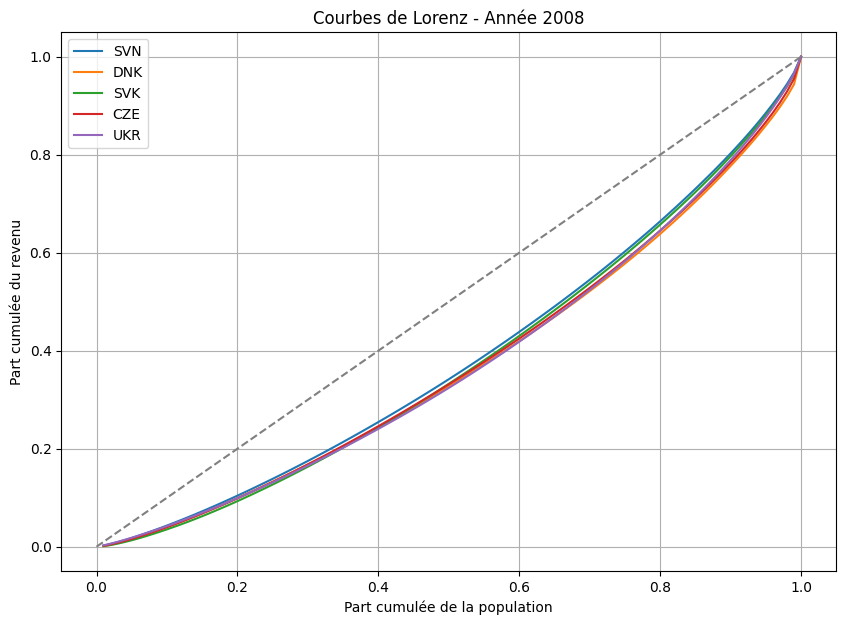

In [105]:
plt.figure(figsize=(10, 7))

for code in best_2008:
    df_pays = df_max[(df_max["country_code"] == code) & (df_max["year"] == 2008)]
    df_pays = df_pays.sort_values("income")

    # Check if df_pays is empty before proceeding
    if not df_pays.empty:
        cum_pop = np.cumsum(df_pays["pop"])
        cum_income = np.cumsum(df_pays["income"] * df_pays["pop"])

        # Normalize cumulative sums if they are not empty
        if not cum_pop.empty and not cum_income.empty:
            cum_pop /= cum_pop.iloc[-1]
            cum_income /= cum_income.iloc[-1]

            plt.plot(cum_pop, cum_income, label=code)
        else:
            print(f"Warning: Cumulative sums are empty for {code} in 2008. Skipping plot for this country.")
    else:
        print(f"Warning: No data found for {code} in 2008. Skipping plot for this country.")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey')  # parfaite égalité
plt.xlabel("Part cumulée de la population")
plt.ylabel("Part cumulée du revenu")
plt.title("Courbes de Lorenz - Année 2008")
plt.legend()
plt.grid(True)
plt.show()

In [106]:
pays_continent.head()

,country_code,country,continent
0,BLR,Belarus,europe
1,CAN,Canada,america
2,GIB,Gibraltar,europe
3,GRC,Greece,europe
4,MNP,Northern Mariana Islands,asia


In [107]:
n_continent =pays_continent["continent"].nunique()
print(f"Nombre de continent distincts : {n_continent}")

Nombre de continent distincts : 5


In [108]:
# Merge des continents dans df_max sur le code pays
df_max = df_max.merge(pays_continent[['country_code', 'continent']], on='country_code', how='left')

# Vérification
print(df_max['continent'].isna().sum())  # nombre de pays sans continent (doit être 0 idéalement)
df_max.head()


100


,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011,pop_pays,pop_mondial,ratio_pop,continent
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe


In [109]:
df_max.loc[df_max["country"] == "Kosovo", "continent"] = "europe"


In [110]:
# Vérification
print(df_max['continent'].isna().sum())  # nombre de pays sans continent (doit être 0 idéalement)
df_max.head()


0


,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011,pop_pays,pop_mondial,ratio_pop,continent
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.3,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe


In [111]:
df_max.to_csv("/content/drive/MyDrive/Projet_7/df_max5.csv")

In [112]:
gini

,country,country_code,2004,2006,2007,2008,2009,2010,2011
0,World,WLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,NaN,NaN,NaN,0.3,NaN,NaN,NaN
3,Algeria,DZA,NaN,NaN,NaN,NaN,NaN,NaN,0.276
4,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
# Nombre d'années d'observation par pays
nb_years_by_country = df_gini2[df_gini2['gini'].notna()].groupby('country')['year'].nunique()

# Filtrer ceux avec 7 années disponibles
pays_complets = nb_years_by_country[nb_years_by_country == 7].index.tolist()

# Filtrage du DataFrame
df_complet = gini[gini['country'].isin(pays_complets)]
pays_complets

['Argentina',
 'Armenia',
 'Austria',
 'Belarus',
 'Belgium',
 'Canada',
 'Costa Rica',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'El Salvador',
 'Estonia',
 'Finland',
 'France',
 'Georgia',
 'Germany',
 'Greece',
 'Honduras',
 'Hungary',
 'Iceland',
 'Indonesia',
 'Ireland',
 'Israel',
 'Italy',
 'Kazakhstan',
 'Kyrgyz Republic',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Moldova',
 'Netherlands',
 'Norway',
 'Panama',
 'Paraguay',
 'Peru',
 'Poland',
 'Portugal',
 'Romania',
 'Russian Federation',
 'Slovak Republic',
 'Slovenia',
 'Spain',
 'Sweden',
 'Switzerland',
 'Thailand',
 'Turkiye',
 'Ukraine',
 'United Kingdom',
 'United States',
 'Uruguay']

In [114]:
df_complet.describe()

,2004,2006,2007,2008,2009,2010,2011
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,36.284615,36.142308,0.358615,0.355654,0.351769,0.350308,0.348962
std,8.611993,8.529243,0.082522,0.079547,0.077273,0.075809,0.075341
min,24.800000,24.400000,0.244000,0.237000,0.248000,0.248000,0.246000
25%,30.075000,29.775000,0.299750,0.292750,0.285000,0.292000,0.280750
50%,33.700000,34.000000,0.339500,0.337000,0.334000,0.336000,0.330500
75%,40.700000,41.150000,0.401250,0.405000,0.396500,0.395000,0.397750
max,58.100000,57.500000,0.558000,0.555000,0.518000,0.531000,0.526000


In [115]:
df_complet['2004'] = df_complet['2004']/ 100

/tmp/ipython-input-3628972959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_complet['2004'] = df_complet['2004']/ 100


In [116]:
df_complet['2006'] = df_complet['2006']/ 100

/tmp/ipython-input-3293910907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_complet['2006'] = df_complet['2006']/ 100


Étape 1 : Dendrogramme (exploration)

Variables utilisées : gini, gdpppp

But : découvrir la structure naturelle des pays sans biais géographique.

Résultat : estimation visuelle du bon nombre de clusters (k).

Étape 2 : KMeans clustering

Variables utilisées : gini, gdpppp, pop_pays

But : créer des clusters plus riches économiquement et démographiquement.

Optionnel : utiliser le k trouvé via dendrogramme ou silhouette.

Étape 3 : Analyse géographique (continent)

Utilisation de continent seulement ici

But :

Voir la répartition géographique des clusters.

Vérifier si certains clusters sont continent-dominants ou mixtes.

Assurer une bonne diversité dans la sélection des pays pour mission 2.

In [117]:
df_complet

,country,country_code,2004,2006,2007,2008,2009,2010,2011
8,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427
9,Armenia,ARM,0.375,0.297,0.312,0.292,0.280,0.300,0.294
12,Austria,AUT,0.298,0.296,0.306,0.304,0.315,0.303,0.308
18,Belarus,BLR,0.265,0.283,0.296,0.278,0.277,0.286,0.272
19,Belgium,BEL,0.305,0.281,0.292,0.284,0.286,0.284,0.281
36,Canada,CAN,0.338,0.341,0.338,0.339,0.340,0.336,0.327
47,Costa Rica,CRI,0.484,0.493,0.493,0.486,0.506,0.480,0.488
52,Cyprus,CYP,0.301,0.311,0.311,0.317,0.321,0.315,0.326
53,Czechia,CZE,0.275,0.267,0.260,0.263,0.262,0.266,0.264
54,Denmark,DNK,0.249,0.259,0.262,0.252,0.267,0.272,0.273


In [118]:
df_max

,country_code,year,quantile,nb_quantiles,income,pop,gdpppp,country,2004,2006,2007,2008,2009,2010,2011,pop_pays,pop_mondial,ratio_pop,continent
0,ALB,2008.0,1.0,100.0,728.89795,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
1,ALB,2008.0,2.0,100.0,916.66235,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
2,ALB,2008.0,3.0,100.0,1010.91600,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
3,ALB,2008.0,4.0,100.0,1086.90780,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
4,ALB,2008.0,5.0,100.0,1132.69970,0.03143,7297.0,Albania,NaN,NaN,NaN,0.30,NaN,NaN,NaN,2992930.0,6.842500e+09,0.044,europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11595,ZAF,2008.0,96.0,100.0,24553.56800,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN,51114599.0,6.842500e+09,0.747,africa
11596,ZAF,2008.0,97.0,100.0,28858.03100,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN,51114599.0,6.842500e+09,0.747,africa
11597,ZAF,2008.0,98.0,100.0,35750.29000,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN,51114599.0,6.842500e+09,0.747,africa
11598,ZAF,2008.0,99.0,100.0,46297.31600,0.48793,9602.0,South Africa,NaN,NaN,NaN,0.63,NaN,0.634,NaN,51114599.0,6.842500e+09,0.747,africa


In [119]:
df_complet = df_complet.merge(
    df_max[[ "country_code", "gdpppp", "income"]].drop_duplicates(),
    on=[ "country_code"],
    how="left"
)


In [120]:
df_complet

,country,country_code,2004,2006,2007,2008,2009,2010,2011,gdpppp,income
0,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,254.08942
1,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,470.50150
2,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,623.45420
3,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,734.97455
4,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,832.31850
...,...,...,...,...,...,...,...,...,...,...,...
5096,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,15500.59900
5097,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,17204.84400
5098,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,19805.24000
5099,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,24409.80300


In [122]:
# Liste des colonnes Gini dans df_complet
gini_cols = ["2004", "2006", "2007", "2008", "2009", "2010", "2011"]

# Calcul de la moyenne du Gini pour chaque pays
df_gini_mean = (
    df_complet.groupby(["country", "country_code"])[gini_cols]
    .mean()
    .mean(axis=1)
    .reset_index(name="gini_mean_2004_2011")
)

df_gini_mean


,country,country_code,gini_mean_2004_2011
0,Argentina,ARG,0.452000
1,Armenia,ARM,0.307143
2,Austria,AUT,0.304286
3,Belarus,BLR,0.279571
4,Belgium,BEL,0.287571
5,Canada,CAN,0.337000
6,Costa Rica,CRI,0.490000
7,Cyprus,CYP,0.314571
8,Czechia,CZE,0.265286
9,Denmark,DNK,0.262000


In [123]:
df_complet= df_complet.merge(df_gini_mean, on=["country", "country_code"], how="left")

In [124]:
df_complet

,country,country_code,2004,2006,2007,2008,2009,2010,2011,gdpppp,income,gini_mean_2004_2011
0,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,254.08942,0.452000
1,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,470.50150,0.452000
2,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,623.45420,0.452000
3,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,734.97455,0.452000
4,Argentina,ARG,0.485,0.464,0.463,0.450,0.438,0.437,0.427,13220.0,832.31850,0.452000
...,...,...,...,...,...,...,...,...,...,...,...,...
5096,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,15500.59900,0.450714
5097,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,17204.84400,0.450714
5098,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,19805.24000,0.450714
5099,Uruguay,URY,0.459,0.459,0.464,0.451,0.455,0.445,0.422,11682.0,24409.80300,0.450714


### dendogramme PIB GINI CONTINENT

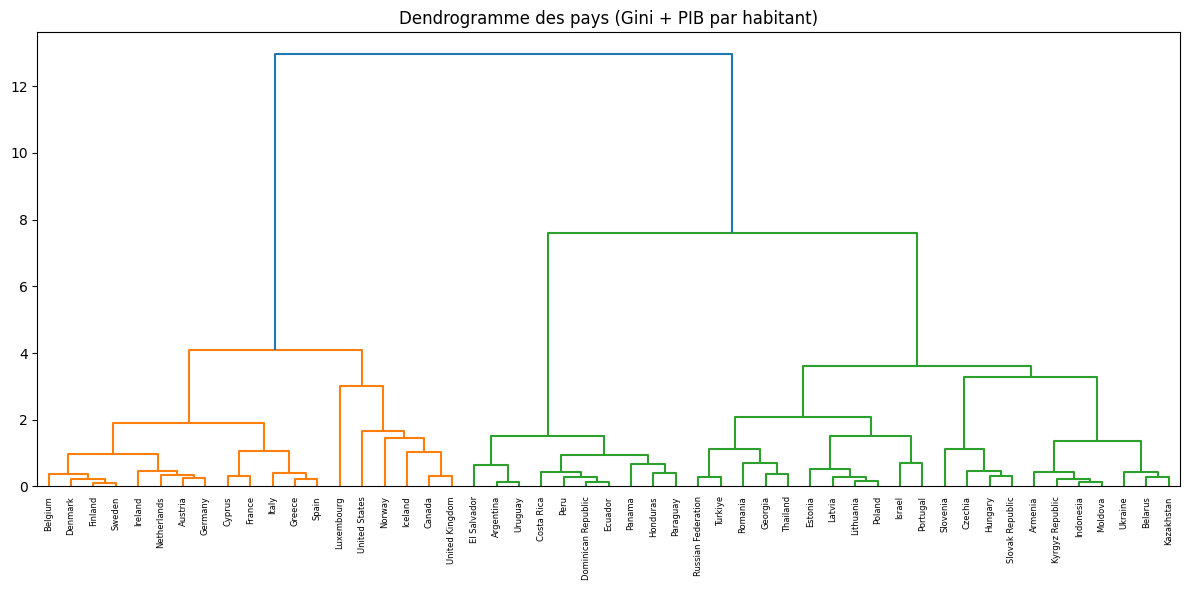

In [125]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Étape 1 : agrégation des données au niveau des pays
df_cluster = (
    df_complet.groupby("country")[["gini_mean_2004_2011", "gdpppp", "income"]]
    .mean()
    .reset_index()
    .dropna()
)

# Étape 2 : standardisation (sans encodage)
X = df_cluster[["gini_mean_2004_2011", "gdpppp","income"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Étape 3 : création du dendrogramme
linked = linkage(X_scaled, method='ward')

# Étape 4 : affichage
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=df_cluster["country"].values, leaf_rotation=90)
plt.title("Dendrogramme des pays (Gini + PIB par habitant)")
plt.tight_layout()
plt.show()


In [126]:
from scipy.cluster.hierarchy import fcluster

# Appliquer le découpage en 4 clusters
df_cluster["cluster"] = fcluster(linked, t=4, criterion="maxclust")

df_cluster = df_cluster[df_cluster["country"] != "Fiji"]



In [127]:
df_cluster.head()

,country,gini_mean_2004_2011,gdpppp,income,cluster
0,Argentina,0.452000,13220.0,5847.884654,3
1,Armenia,0.307143,5611.0,1628.382785,4
2,Austria,0.304286,36193.0,16637.600204,1
3,Belarus,0.279571,11651.0,3921.163534,4
4,Belgium,0.287571,33561.0,15024.614176,1


In [128]:
df_cluster.to_csv("/content/drive/MyDrive/Projet_7/df_cluster2.csv")


Visuellement nous allons choisir K=4
Nous allons supprimer le cluster des Fiji qui doit contenir une anomalie dans la data

In [129]:
df_cluster.groupby("cluster")[["gini_mean_2004_2011", "gdpppp", "income"]].mean()


,gini_mean_2004_2011,gdpppp,income
cluster,,,
1,0.306604,32556.230769,16163.175872
2,0.327167,45321.333333,24257.045978
3,0.491343,8421.100000,4155.644615
4,0.331909,13563.636364,5345.375785


In [130]:
# Regrouper les pays par cluster
cluster_dict = df_cluster.groupby("cluster")["country"].apply(list).to_dict()

# Affichage clair de chaque cluster
for cluster_id, countries in cluster_dict.items():
    print(f"Cluster {cluster_id} :")
    print(", ".join(countries))
    print("-" * 50)


Cluster 1 :
Austria, Belgium, Cyprus, Denmark, Finland, France, Germany, Greece, Ireland, Italy, Netherlands, Spain, Sweden
--------------------------------------------------
Cluster 2 :
Canada, Iceland, Luxembourg, Norway, United Kingdom, United States
--------------------------------------------------
Cluster 3 :
Argentina, Costa Rica, Dominican Republic, Ecuador, El Salvador, Honduras, Panama, Paraguay, Peru, Uruguay
--------------------------------------------------
Cluster 4 :
Armenia, Belarus, Czechia, Estonia, Georgia, Hungary, Indonesia, Israel, Kazakhstan, Kyrgyz Republic, Latvia, Lithuania, Moldova, Poland, Portugal, Romania, Russian Federation, Slovak Republic, Slovenia, Thailand, Turkiye, Ukraine
--------------------------------------------------


* Cluster 1 – Europe de l’Ouest (pays riches, égalitaires/modérés)

Autriche, Belgique, France, Allemagne, Espagne, Suède…

* Cluster 2 – Pays anglo-saxons riches

Canada, Luxembourg, Norvège, USA…

* Cluster 3 – Amérique latine (inégalités fortes)

Argentine, Paraguay, Pérou, Uruguay…

* Cluster 4 – Europe de l’Est / Asie Centrale / Pays en transition

Armenia, Belarus, Estonia, Kazakhstan, Lithuania, Poland…

Nous avons appliqué un clustering hiérarchique (dendrogramme), qui a révélé quatre groupes cohérents et interprétables de pays.
Les clusters obtenus correspondent à des zones économiques et sociales homogènes.
Dans ce contexte, un K-means ne serait pas utile : il imposerait des clusters sphériques et pourrait dégrader la structuration hiérarchique naturelle mise en évidence par le dendrogramme.
Nous conservons donc les clusters hiérarchiques comme classification finale.

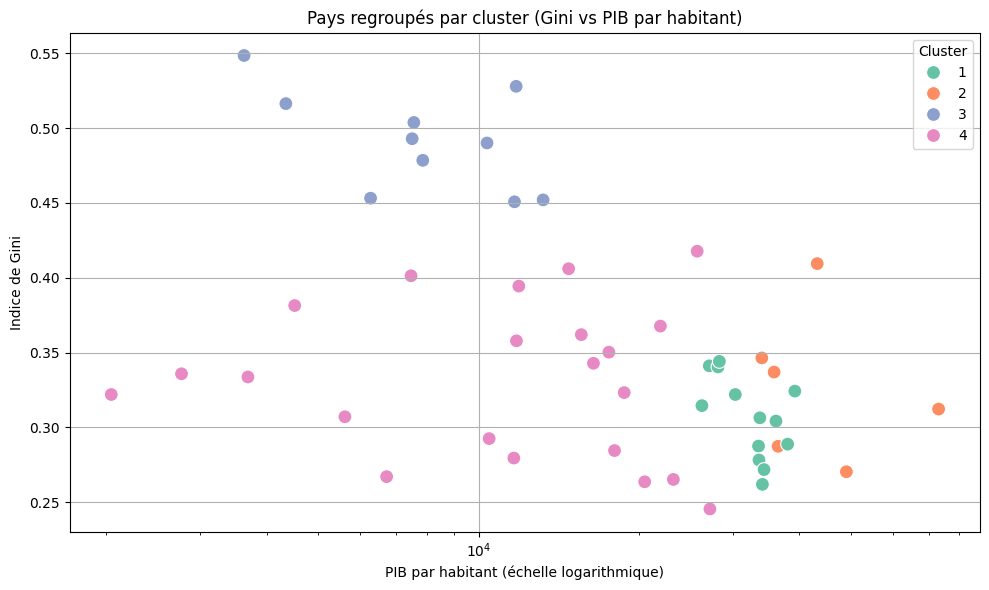

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du graphique
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cluster,
    x="gdpppp",
    y="gini_mean_2004_2011",
    hue="cluster",
    palette="Set2",
    s=100
)

# Échelle logarithmique pour le PIB
plt.xscale("log")

# Titres et labels
plt.title("Pays regroupés par cluster (Gini vs PIB par habitant)")
plt.xlabel("PIB par habitant (échelle logarithmique)")
plt.ylabel("Indice de Gini")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


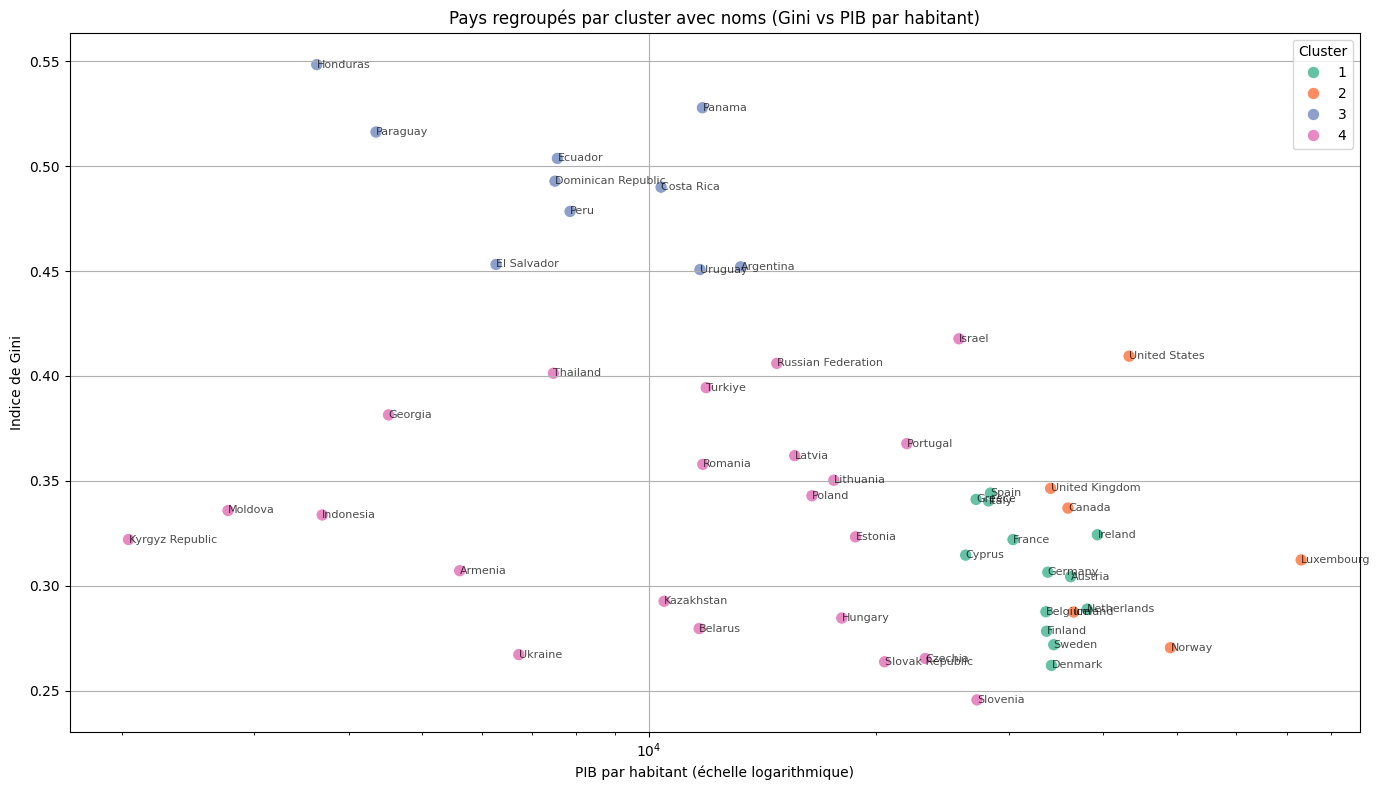

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Scatterplot des clusters
sns.scatterplot(
    data=df_cluster,
    x="gdpppp",
    y="gini_mean_2004_2011",
    hue="cluster",
    palette="Set2",
    s=80,
    legend="full"
)

# Échelle logarithmique pour le PIB
plt.xscale("log")

# Ajouter les noms des pays
for i, row in df_cluster.iterrows():
    plt.text(
        row["gdpppp"], row["gini_mean_2004_2011"], row["country"],
        fontsize=8, alpha=0.7, ha='left', va='center'
    )

# Titres et axes
plt.title("Pays regroupés par cluster avec noms (Gini vs PIB par habitant)")
plt.xlabel("PIB par habitant (échelle logarithmique)")
plt.ylabel("Indice de Gini")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Cluster")
plt.show()


**Pourquoi faire une silhouette après le dendrogramme ?**

Le dendrogramme t’aide à avoir une idée visuelle du nombre de clusters (ex. : 3, 4, 5).

Le coefficient de silhouette te donne une mesure quantitative de la cohérence des clusters pour différents k.

**Rappel : Qu’est-ce que la silhouette ?**

Pour chaque valeur de k (nombre de clusters), elle mesure :

à quel point les objets d’un même cluster sont similaires entre eux,

et différents des autres clusters.

Sa valeur est entre -1 et 1 :

1 : bonne séparation, bons clusters

0 : clusters se chevauchent

< 0 : mauvais regroupement

In [133]:
# Créer une liste pour stocker les pays sélectionnés
selected_countries = []

# Parcourir chaque cluster du dendrogramme
for cluster_id, group in df_cluster.groupby("cluster"):
    temp = group.copy()

    # GINI : pays avec min, max, et proche de la moyenne
    gini_mean = temp["gini_mean_2004_2011"].mean()
    gini_min = temp.loc[temp["gini_mean_2004_2011"].idxmin()]
    gini_max = temp.loc[temp["gini_mean_2004_2011"].idxmax()]
    gini_closest = temp.iloc[(temp["gini_mean_2004_2011"] - gini_mean).abs().argsort()[:1]].squeeze()

    # PIB : pays avec min, max, et proche de la moyenne
    pib_mean = temp["gdpppp"].mean()
    pib_min = temp.loc[temp["gdpppp"].idxmin()]
    pib_max = temp.loc[temp["gdpppp"].idxmax()]
    pib_closest = temp.iloc[(temp["gdpppp"] - pib_mean).abs().argsort()[:1]].squeeze()

    # Ajouter les pays sélectionnés
    selected_countries.extend([
        gini_min["country"],
        gini_closest["country"],
        gini_max["country"],
        pib_min["country"],
        pib_closest["country"],
        pib_max["country"]
    ])

# Supprimer les doublons (au cas où un même pays apparaît 2×)
selected_countries = list(dict.fromkeys(selected_countries))

# Extraire leurs données complètes
selected_df = df_cluster[df_cluster["country"].isin(selected_countries)].reset_index(drop=True)

# Afficher le résultat
selected_df = selected_df.merge(df_max[["country", "country_code"]].drop_duplicates(), on="country", how="left")
selected_df


,country,gini_mean_2004_2011,gdpppp,income,cluster,country_code
0,Argentina,0.452000,13220.0,5847.884654,3,ARG
1,Belgium,0.287571,33561.0,15024.614176,1,BEL
2,Canada,0.337000,35895.0,23739.640518,2,CAN
3,Costa Rica,0.490000,10374.0,5580.386556,3,CRI
4,Cyprus,0.314571,26273.0,17345.387463,1,CYP
5,Denmark,0.262000,34130.0,17043.146491,1,DNK
6,Germany,0.306429,33758.0,18061.718142,1,DEU
7,Honduras,0.548429,3628.0,3296.268419,3,HND
8,Indonesia,0.333714,3689.0,1334.618297,4,IDN
9,Ireland,0.324286,39268.0,17710.735838,1,IRL


In [134]:


# Fusionner la population dans selected_df
selected_df = selected_df.merge(
    df_max[["country_code", "pop_pays"]].drop_duplicates(),
    on="country_code",
    how="left"
)


In [135]:
selected_df.to_csv("/content/drive/MyDrive/Projet_7/selected_df2.csv")


In [136]:
selected_df.head(24)

,country,gini_mean_2004_2011,gdpppp,income,cluster,country_code,pop_pays
0,Argentina,0.452000,13220.0,5847.884654,3,ARG,40424148.0
1,Belgium,0.287571,33561.0,15024.614176,1,BEL,10709708.0
2,Canada,0.337000,35895.0,23739.640518,2,CAN,33449085.0
3,Costa Rica,0.490000,10374.0,5580.386556,3,CRI,4440056.0
4,Cyprus,0.314571,26273.0,17345.387463,1,CYP,1091026.0
5,Denmark,0.262000,34130.0,17043.146491,1,DNK,5493764.0
6,Germany,0.306429,33758.0,18061.718142,1,DEU,81110777.0
7,Honduras,0.548429,3628.0,3296.268419,3,HND,8012587.0
8,Indonesia,0.333714,3689.0,1334.618297,4,IDN,243220028.0
9,Ireland,0.324286,39268.0,17710.735838,1,IRL,4485999.0


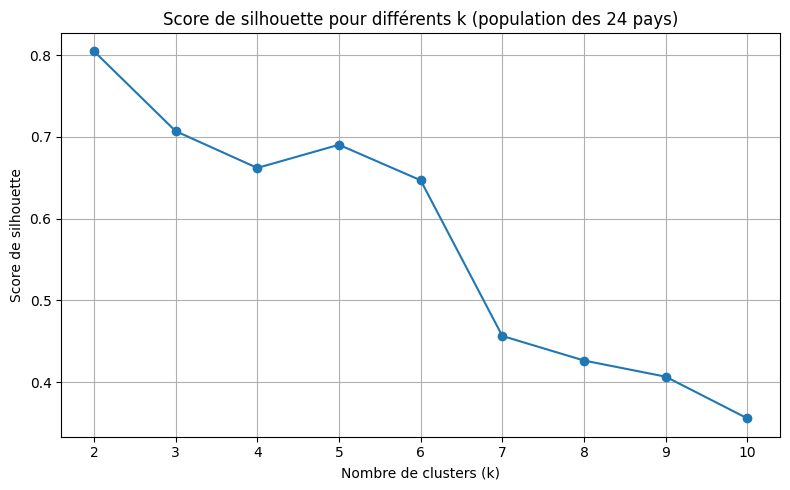

In [137]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Étape 1 : Standardiser la population
X_pop = selected_df[["pop_pays"]].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pop)

# Étape 2 : Calcul des scores de silhouette pour k de 2 à 10
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Étape 3 : Visualiser le score de silhouette
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Score de silhouette pour différents k (population des 24 pays)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()


In [138]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Étape 1 : Préparer les données
X_pop = selected_df[["pop_pays"]].dropna()

# Étape 2 : Standardiser
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pop)

# Étape 3 : Appliquer KMeans avec k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
selected_df["pop_cluster"] = kmeans.fit_predict(X_scaled)

# Étape 4 : Voir les résultats
selected_df[["country", "pop_pays", "pop_cluster"]].sort_values("pop_cluster")
selected_df.head(24)



ValueError: Length of values (18) does not match length of index (21)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Créer la figure 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracer les points en 3D
scatter = ax.scatter(
    selected_df["gdpppp"],
    selected_df["gini"],
    selected_df["pop_pays"],
    c=selected_df["pop_cluster"],
    cmap='Set2',
    s=80
)

# Ajouter les noms des pays
for i, row in selected_df.iterrows():
    ax.text(
        row["gdpppp"],
        row["gini"],
        row["pop_pays"],
        row["country"],
        size=8
    )

# Étiquettes des axes
ax.set_xlabel("PIB par habitant (gdpppp)")
ax.set_ylabel("Indice de Gini")
ax.set_zlabel("Population (pop_pays)")
ax.set_title("KMeans 3D : Gini, PIB et Population")
plt.tight_layout()
plt.show()


In [ ]:
selected_df

Dans un premier temps, j’ai utilisé un clustering par K-Means pour explorer les profils de pays selon leur revenu (PIB par habitant), inégalités (indice de Gini) et population.

Cela m’a permis de repérer certains extrêmes, mais les résultats manquaient de clarté géographique et logique.

Le découpage obtenu était difficile à interpréter et mélangeait des pays très différents.

➤ J’ai donc préféré une approche hiérarchique avec dendrogramme, plus lisible et plus utile pour sélectionner des pays représentatifs.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrage des pays valides (ceux avec données complètes sur les déciles)
pays_valides = ["Bhutan", "Bulgaria", "France", "Liberia", "Norway", "Russian Federation", "South Africa", "United States of America", "Venezuela (Bolivarian Republic of)"]
df_selected_valid = df_main[df_main["country"].isin(pays_valides)]

plt.figure(figsize=(15,10))

for x in pays_valides:
    data = df_max[df_max.country == x]
    plt.plot(data['quantile'], np.log10(data['income']), label=x)

plt.title("Distribution des revenus", fontsize=20, fontweight='bold')
plt.xlabel("Classes de revenus", fontsize=15, fontweight='bold')
plt.ylabel("Revenu moyen", fontsize=15, fontweight='bold')
plt.legend()
plt.show()

In [ ]:
#Courbe de Lorenz
plt.figure(figsize = (15, 12))
list_gini = []

for count in pays_valides:
    # revenus_total_pays : Revenus total sur les 100 centiles
    revenus_total_pays = df_max[df_max.country==count]['income'].sum()

    dep = df_max[df_max.country==count]['income'].values
    n = len(dep)

    # lorenz : Courbe de lorenz
    lorenz = (np.cumsum(np.sort(df_max[df_max.country==count]['income']))/revenus_total_pays)*100
    lorenz = np.append([0],lorenz)
    x = np.append([0],df_max[df_max.country==count]['quantile'])
    plt.plot(x,lorenz,linewidth=3, label=count)


plt.plot([0,100],[0,100],'grey',linestyle='--',linewidth=1.5, label='Cas parfaitement égalitaire')
plt.xlabel('Quantile de la population',fontsize=15,fontweight = 'bold')
plt.ylabel('% cumulé des revenus',fontsize=15,fontweight = 'bold')
plt.legend(loc='upper left',fontsize=10)
plt.grid(True,linestyle='--')
plt.title('Courbe de Lorenz : Population et revenus',fontsize=25,fontweight = 'bold')

plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

# Filtrage et tracé pour chaque pays
for country in pays_valides:
    df_country = df_max[df_max["country"] == country]
    df_country = df_country.sort_values("year")
    plt.plot(df_country["year"], df_country["gini"], linewidth=2, label=country)

plt.title("Évolution de l'indice de Gini", fontsize=20, fontweight='bold')
plt.xlabel("Années", fontsize=15, fontweight='bold')
plt.ylabel("Indice de Gini", fontsize=15, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_main[df_main["country"].isin(pays_valides)][["country", "year", "gini"]].dropna().head(20)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for country in pays_valides:
    df_country = df_main[(df_main["country"] == country) & (df_main["gini"].notna())]
    if not df_country.empty:
        df_country = df_country.sort_values("year")
        plt.plot(df_country["year"], df_country["gini"], linewidth=2, label=country)

plt.title("Évolution de l'indice de Gini", fontsize=20, fontweight='bold')
plt.xlabel("Années", fontsize=15, fontweight='bold')
plt.ylabel("Indice de Gini", fontsize=15, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
for country in pays_valides:
    df_country = df_max[df_max["country"] == country]
    plt.plot(df_country["year"], df_country["gini"], linewidth=2, label=country)

plt.title("Évolution de l'indice de Gini entre 2004 et 2011", fontsize=20, fontweight='bold')
plt.xlabel("Années", fontsize=15, fontweight='bold')
plt.ylabel("Indice de Gini", fontsize=15, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrage des pays valides (ceux avec données complètes sur les déciles)
pays_valides = ["Bhutan", "Bulgaria", "France", "Liberia", "Norway", "Russian Federation", "South Africa", "United States of America", "Venezuela (Bolivarian Republic of)"]
df_selected_valid = df_main[df_main["country"].isin(pays_valides)]

plt.figure(figsize=(15,10))

for x in pays_valides:
    data = df_max[df_max.country == x]
    plt.plot(data['quantile'], np.log10(data['income']), label=x)

plt.title("Distribution des revenus", fontsize=20, fontweight='bold')
plt.xlabel("Classes de revenus", fontsize=15, fontweight='bold')
plt.ylabel("Revenu moyen", fontsize=15, fontweight='bold')
plt.legend()
plt.show()

In [ ]:
frique

Europe: Norway et Luxembourg republique Tchek

Asie: RUssie Khazakstan indonesia

Afrique: Afrique du Sud, Liberia

Amerique : USA Mexico Venezuela



In [ ]:
country_list = ['Bulgaria', 'United States of America', 'Spain', 'France', 'Crotia', 'Norway', 'United States', 'Denmark', 'Austria']
country_code = ['LUX', 'SWE', 'ESP', 'FRA', 'HRV', 'NOR', 'USA', 'DNK', 'AUT']